# Cell 1: Setup

In [11]:
import wfdb
import wfdb.processing
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from collections import Counter
import pandas as pd
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Cell 2: Bandpass filter function (same as D2)

In [2]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=2):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# Cell 3: Function to process one record

In [3]:
def process_record(record_id, data_dir='data/mitdb'):
    # Download if not present
    record_path = os.path.join(data_dir, str(record_id))
    if not os.path.exists(record_path + '.hea'):
        wfdb.dl_database('mitdb', dl_dir=data_dir, records=[str(record_id)])

    # Load full record
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, 'atr')

    signal = record.p_signal[:, 0]  # MLII channel
    fs = record.fs

    # Filter
    filtered = bandpass_filter(signal, fs)

    # Detect R-peaks
    peaks = wfdb.processing.gqrs_detect(filtered, fs=fs)

    # Segment beats
    window_before = int(0.2 * fs)
    window_after = int(0.4 * fs)

    beats = []
    valid_peaks = []
    for peak in peaks:
        start = peak - window_before
        end = peak + window_after
        if start >= 0 and end < len(filtered):
            beats.append(filtered[start:end])
            valid_peaks.append(peak)

    # Match labels — use nearest annotation within 20 samples
    beat_labels = []
    ann_samples = annotation.sample.astype(np.int64)
    ann_symbols = annotation.symbol
    non_beat = {'+', '~', '|', 'x', '[', ']', '(', ')'}

    for peak in valid_peaks:
        diffs = np.abs(ann_samples - peak)
        idx = np.argmin(diffs)
        if diffs[idx] <= 20 and ann_symbols[idx] not in non_beat:
            beat_labels.append(ann_symbols[idx])
        else:
            beat_labels.append('U')

    print(f"Record {record_id}: {len(beats)} beats, labels: {Counter(beat_labels)}")
    return beats, valid_peaks, beat_labels, fs

# Cell 4: Process all four records

In [4]:
records_to_use = ['100', '106', '109', '212']

all_beats = []
all_peaks_list = []
all_labels = []
all_fs = None

for rec_id in records_to_use:
    beats, peaks, labels, fs = process_record(rec_id)
    all_beats.extend(beats)
    all_peaks_list.append(peaks)
    all_labels.extend(labels)
    all_fs = fs

print(f"\nTotal beats: {len(all_beats)}")
print(f"Total labels: {Counter(all_labels)}")

Record 100: 2271 beats, labels: Counter({'N': 2237, 'A': 33, 'V': 1})
Record 106: 2032 beats, labels: Counter({'N': 1506, 'V': 512, 'U': 14})
Record 109: 2531 beats, labels: Counter({'L': 2491, 'V': 34, 'U': 4, 'F': 2})
Record 212: 2749 beats, labels: Counter({'R': 1825, 'N': 922, 'U': 2})

Total beats: 9583
Total labels: Counter({'N': 4665, 'L': 2491, 'R': 1825, 'V': 547, 'A': 33, 'U': 20, 'F': 2})


# Cell 5: Feature extraction function

In [5]:
def extract_features(beats, peaks, fs):
    window_before = int(0.2 * fs)
    window_after = int(0.4 * fs)
    p_wave_end = int(0.08 * fs)      # P-wave in first 80ms of window
    t_wave_start = int(0.25 * fs)    # T-wave starts 50ms after R-peak

    features = []
    rr_intervals = np.diff(peaks)
    # Prepend first RR to keep length consistent
    rr_intervals = np.concatenate([[rr_intervals[0]], rr_intervals])

    for i, beat in enumerate(beats):
        rr = rr_intervals[i] / fs * 1000          # ms
        rr_prev = rr_intervals[i-1] / fs * 1000 if i > 0 else rr
        rr_ratio = rr / rr_prev if rr_prev > 0 else 1.0

        r_amplitude = beat[window_before]          # value at R-peak index
        r_amplitude_max = beat[window_before-2:window_before+3].max()

        p_wave_amp = beat[:p_wave_end].max()       # P-wave region
        t_wave_amp = beat[window_before + t_wave_start:].max()  # T-wave region

        # QRS duration: samples above 50% of R amplitude
        qrs_region = beat[window_before - int(0.05*fs): window_before + int(0.05*fs)]
        threshold = 0.5 * r_amplitude_max
        qrs_duration = np.sum(qrs_region > threshold) / fs * 1000  # ms

        beat_mean = beat.mean()
        beat_std = beat.std()

        features.append([
            rr,
            rr_ratio,
            r_amplitude_max,
            qrs_duration,
            p_wave_amp,
            t_wave_amp,
            beat_mean,
            beat_std
        ])

    return np.array(features)

# Cell 6: Extract features per record and combine

In [6]:
feature_list = []
label_list = []

start_idx = 0
for i, rec_id in enumerate(records_to_use):
    beats, peaks, labels, fs = process_record(rec_id)
    feats = extract_features(beats, peaks, fs)
    feature_list.append(feats)
    label_list.extend(labels)

X = np.vstack(feature_list)
y = np.array(label_list)

feature_names = [
    'RR_interval_ms',
    'RR_ratio',
    'R_amplitude',
    'QRS_duration_ms',
    'P_wave_amplitude',
    'T_wave_amplitude',
    'beat_mean',
    'beat_std'
]

print(f"Feature matrix shape: {X.shape}")
print(f"Label array shape: {y.shape}")
print(f"Class distribution: {Counter(y)}")

Record 100: 2271 beats, labels: Counter({'N': 2237, 'A': 33, 'V': 1})
Record 106: 2032 beats, labels: Counter({'N': 1506, 'V': 512, 'U': 14})
Record 109: 2531 beats, labels: Counter({'L': 2491, 'V': 34, 'U': 4, 'F': 2})
Record 212: 2749 beats, labels: Counter({'R': 1825, 'N': 922, 'U': 2})
Feature matrix shape: (9583, 8)
Label array shape: (9583,)
Class distribution: Counter({'N': 4665, 'L': 2491, 'R': 1825, 'V': 547, 'A': 33, 'U': 20, 'F': 2})


# Cell 7: Remove unlabelled beats

In [7]:
mask = y != 'U'
X = X[mask]
y = y[mask]
print(f"After removing unlabelled: {X.shape[0]} beats")
print(f"Class distribution: {Counter(y)}")

After removing unlabelled: 9563 beats
Class distribution: Counter({'N': 4665, 'L': 2491, 'R': 1825, 'V': 547, 'A': 33, 'F': 2})


# Cell 8: Plot class distribution

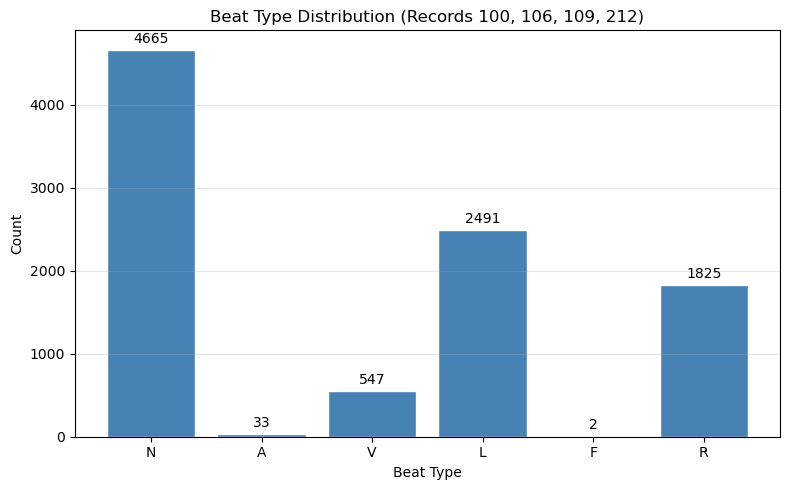

Saved: figures/class_distribution.png


In [8]:
class_counts = Counter(y)
classes = list(class_counts.keys())
counts = list(class_counts.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(classes, counts, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Beat Type')
ax.set_ylabel('Count')
ax.set_title('Beat Type Distribution (Records 100, 106, 109, 212)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150)
plt.show()
print("Saved: figures/class_distribution.png")

# Cell 9: Plot feature distributions

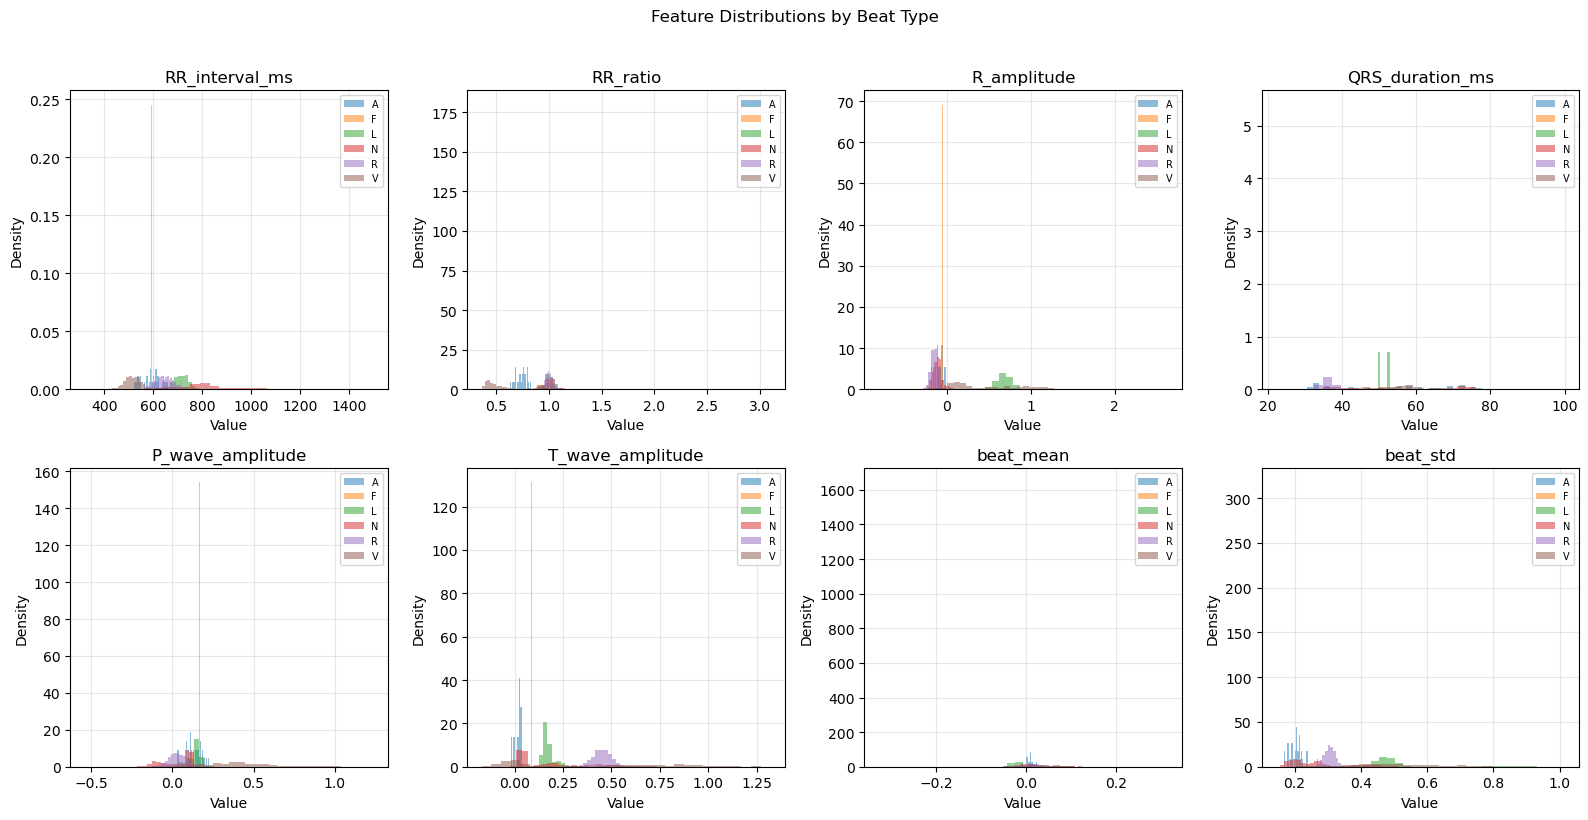

Saved: figures/feature_distributions.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (feat_name, ax) in enumerate(zip(feature_names, axes)):
    for label in sorted(set(y)):
        ax.hist(X[y == label, i], bins=30, alpha=0.5, label=label, density=True)
    ax.set_title(feat_name)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Beat Type', y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/feature_distributions.png")

# Cell 7b: Drop F class (too few samples)

In [14]:
mask = (y != 'F')
X = X[mask]
y = y[mask]
print(f"After dropping F: {X.shape[0]} beats")
print(f"Final class distribution: {Counter(y)}")

After dropping F: 9561 beats
Final class distribution: Counter({'N': 4665, 'L': 2491, 'R': 1825, 'V': 547, 'A': 33})


# Cell 10: Save feature matrix

In [15]:
np.savez('data/feature_matrix.npz',
         X=X,
         y=y,
         feature_names=np.array(feature_names))
print("Saved: data/feature_matrix.npz")
print(f"\nFinal dataset: {X.shape[0]} beats, {X.shape[1]} features")
print(f"Classes: {sorted(set(y))}")

Saved: data/feature_matrix.npz

Final dataset: 9561 beats, 8 features
Classes: ['A', 'L', 'N', 'R', 'V']
